# CNASim Performance

The experiment evaluates tree reconstruction performance on CNAsim data. This notebook shows the workflow steps.

In [1]:
# autoreload
%load_ext autoreload
%autoreload 2

In [2]:
import os

import scgenome.plotting as pl
import anndata
import pandas as pd
from Bio import Phylo
from io import StringIO

from cellmates.utils.tree_utils import write_newick, nxtree_to_newick, newick_to_nx


/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [69]:
# data is generated from CNAsim

In [70]:
# converted to anndata

In [4]:
data_path = "../../results/data/R1_N10_M100_K2_L2_E10.04_E20.1_C2"

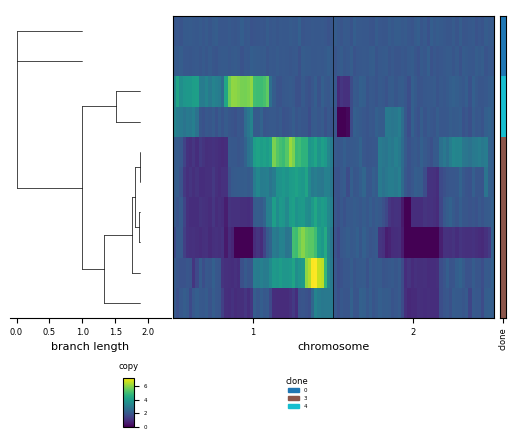

In [5]:
# plot example
adata = anndata.read_h5ad(os.path.join(data_path, "input.h5ad"))
bio_tree = Phylo.read(StringIO(adata.uns['cell-tree-newick']), 'newick')
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', tree=bio_tree, annotation_fields=['clone'], raw=True)

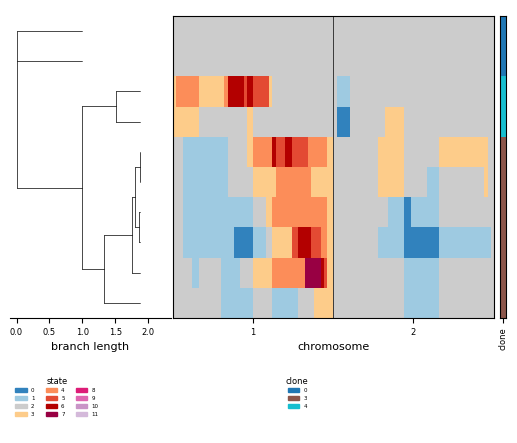

In [6]:
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=bio_tree, annotation_fields=['clone'])

In [7]:
gt_tree_nwk = adata.uns['cell-tree-newick']
print(gt_tree_nwk)

(cell1:1.0,cell2:1.0,((cell3:0.3630717518763287,cell4:0.3630717518763287)ancestor1:0.5110173170298968,((((cell7:0.0043867592967052,cell8:0.0043867592967052)ancestor5:0.06288212595246571,(cell10:0.01027196580340416,cell9:0.01027196580340416)ancestor6:0.05699691944576676)ancestor4:0.04755067586255669,cell6:0.11481956111172761)ancestor3:0.42274633639258163,cell5:0.5375658975043093)ancestor2:0.33652317140191623)founder:1.0)root;


In [8]:
print(bio_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=1.0, name='cell1')
        Clade(branch_length=1.0, name='cell2')
        Clade(branch_length=1.0, name='founder')
            Clade(branch_length=0.5110173170298968, name='ancestor1')
                Clade(branch_length=0.3630717518763287, name='cell3')
                Clade(branch_length=0.3630717518763287, name='cell4')
            Clade(branch_length=0.33652317140191623, name='ancestor2')
                Clade(branch_length=0.42274633639258163, name='ancestor3')
                    Clade(branch_length=0.04755067586255669, name='ancestor4')
                        Clade(branch_length=0.06288212595246571, name='ancestor5')
                            Clade(branch_length=0.0043867592967052, name='cell7')
                            Clade(branch_length=0.0043867592967052, name='cell8')
                        Clade(branch_length=0.05699691944576676, name='ancestor6')
                            Clade(bran

In [9]:
em_nwk = open(os.path.join(data_path, "cm_out", "tree.nwk")).read()
print(em_nwk)

(((((((((cell8:0.005105647151597669,cell9:0.003521362748037286)ancestor8:0.001779955779563772,cell3:0.0034073165531906587)ancestor7:8.95235076603404e-12,cell10:2.1855929764447783e-13)ancestor6:1.0927964882223891e-13,cell1:1.0927964882223891e-13)ancestor5:5.4639824411119456e-14,cell6:5.4639824411119456e-14)ancestor4:2.7319912205559728e-14,cell7:2.7319912205559728e-14)ancestor3:1.3659956102779864e-14,cell5:1.3659956102779864e-14)ancestor2:6.829978051389932e-15,cell4:6.829978051389932e-15)ancestor1:6.829978051389932e-15,cell2:1.509515616563695e-13)root;


In [10]:
inferred_tree = Phylo.read(os.path.join(data_path, "cm_out", "tree.nwk"), 'newick')

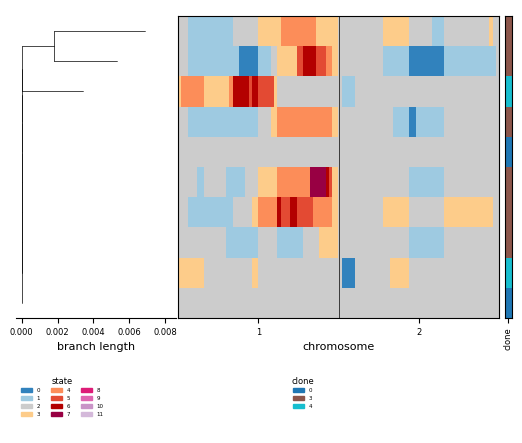

In [11]:
# output tree
# print(inferred_tree)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='state', tree=inferred_tree, annotation_fields=['clone'])


In [12]:
print(inferred_tree)

Tree(rooted=False, weight=1.0)
    Clade(name='root')
        Clade(branch_length=6.829978051389932e-15, name='ancestor1')
            Clade(branch_length=6.829978051389932e-15, name='ancestor2')
                Clade(branch_length=1.3659956102779864e-14, name='ancestor3')
                    Clade(branch_length=2.7319912205559728e-14, name='ancestor4')
                        Clade(branch_length=5.4639824411119456e-14, name='ancestor5')
                            Clade(branch_length=1.0927964882223891e-13, name='ancestor6')
                                Clade(branch_length=8.95235076603404e-12, name='ancestor7')
                                    Clade(branch_length=0.001779955779563772, name='ancestor8')
                                        Clade(branch_length=0.005105647151597669, name='cell8')
                                        Clade(branch_length=0.003521362748037286, name='cell9')
                                    Clade(branch_length=0.0034073165531906587, name='cel